# Scaling Comparison

Plot interval vs. MAC count for `pl_scaling_L.csv`, `pl_scaling_R.csv`, and `aie_scaling.csv`.


In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

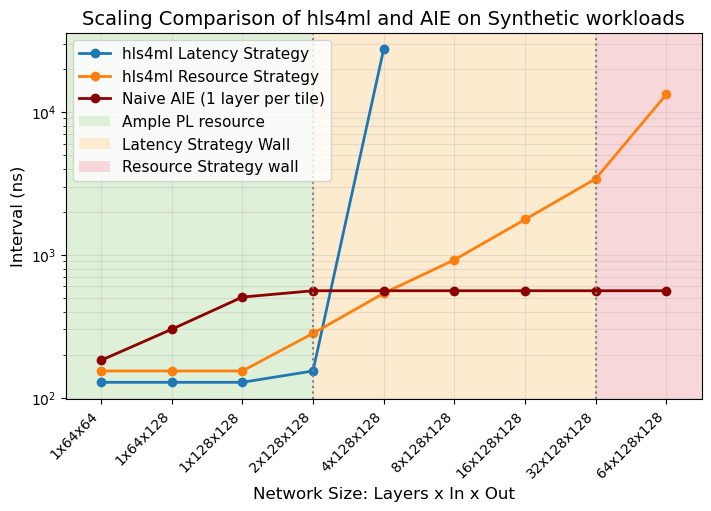

In [22]:
figsize = (7, 5)
l_color = "#1f77b4"
r_color = "#ff7f0e"
aie_color = "#8b0000"
left_region_color = "#dff0d8"
mid_region_color = "#fdebd0"
right_region_color = "#f8d7da"
region_alpha = 1.0

base = Path(".")


def read_local_csv(name):
    path = base / name
    if not path.exists():
        path = Path("dense_exp/scale_plot") / name
    return pd.read_csv(path)


def add_shape(df):
    df = df.copy()
    df["MACs"] = df["in"] * df["out"] * df["layers"]
    df["shape"] = (
        df["layers"].astype(int).astype(str)
        + "x"
        + df["in"].astype(int).astype(str)
        + "x"
        + df["out"].astype(int).astype(str)
    )
    return df.sort_values("MACs")


l_df = add_shape(read_local_csv("pl_scaling_L.csv"))
r_df = add_shape(read_local_csv("pl_scaling_R.csv"))
aie_df = add_shape(read_local_csv("aie_scaling.csv"))

shape_order = (
    pd.concat([
        l_df[["shape", "MACs"]],
        r_df[["shape", "MACs"]],
        aie_df[["shape", "MACs"]],
    ])
    .drop_duplicates("shape")
    .sort_values("MACs")
)
x_map = {shape: i for i, shape in enumerate(shape_order["shape"])}

left_split = x_map["2x128x128"]
right_split = x_map["32x128x128"]

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
ax.axvspan(-0.5, left_split, color=left_region_color, alpha=region_alpha, zorder=0)
ax.axvspan(left_split, right_split, color=mid_region_color, alpha=region_alpha, zorder=0)
ax.axvspan(right_split, len(shape_order) - 0.5, color=right_region_color, alpha=region_alpha, zorder=0)

ax.plot([x_map[s] for s in l_df["shape"]], l_df["interval(ns)"]*3.2/4.0, marker="o", linewidth=2, color=l_color, label="hls4ml Latency Strategy", )
ax.plot([x_map[s] for s in r_df["shape"]], r_df["interval(ns)"]*3.2/4.0, marker="o", linewidth=2, color=r_color, label="hls4ml Resource Strategy")
ax.plot([x_map[s] for s in aie_df["shape"]], aie_df["interval(ns)"], marker="o", linewidth=2, color=aie_color, label="Naive AIE (1 layer per tile)")
ax.axvline(left_split, color="#808080", linestyle=":", linewidth=1.5)
ax.axvline(right_split, color="#808080", linestyle=":", linewidth=1.5)

ax.set_title("Scaling Comparison of hls4ml and AIE on Synthetic workloads", fontsize=14)
ax.set_xlabel("Network Size: Layers x In x Out", fontsize=12)
ax.set_ylabel("Interval (ns)", fontsize=12)
ax.set_yscale("log", base=10)
ax.set_xlim(-0.5, len(shape_order) - 0.5)
ax.margins(x=0)
ax.set_xticks(range(len(shape_order)))
ax.set_xticklabels(shape_order["shape"], rotation=45, ha="right")
ax.tick_params(axis="both", labelsize=10)
ax.grid(alpha=0.3, which="both")
region_handles = [
    Patch(facecolor=left_region_color, alpha=region_alpha, label="Ample PL resource"),
    Patch(facecolor=mid_region_color, alpha=region_alpha, label="Latency Strategy Wall"),
    Patch(facecolor=right_region_color, alpha=region_alpha, label="Resource Strategy wall"),
]
line_handles, line_labels = ax.get_legend_handles_labels()
ax.legend(line_handles + region_handles, line_labels + [h.get_label() for h in region_handles], loc="upper left", fontsize=11)

plt.show()
